## CS310 Natural Language Processing
## Assignment 2. Word2vec Implementation 

**Total points**: 30

Train a word2vec model using the **skip-gram** architecture and **negative sampling**.

You should roughtly follow the structure of the notebook. Add additional cells if you feel needed. 

You can (and you should) re-use the code from *Lab 3: Data preparation for implementing word2vec*. 

Make sure your code is readable and well-structured.

## 0. Import Necessary Libraries

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from gensim.models import KeyedVectors

from a2_word2vec_experiment import (
    ANALOGY_TOPN,
    DEVICE,
    NEGATIVE_TABLE_SIZE,
    SEED,
    SkipGram,
    batchify,
    collect_raw_stats,
    generate_data,
    iter_corpus_lines,
    prepare_corpus,
    run_experiments,
)


## 1. Data Processing

The corpus data is in `shakespeare.txt`. Use the `CorpusReader` class in `utils.py` to help you.

In [2]:
INPUT_FILE = "shakespeare.txt"
ANALOGY_FILE = "questions-words-shakespeare.csv"
OUTPUT_DIR = "."

raw_corpus_stats, token_counter = collect_raw_stats(INPUT_FILE)
print("Teacher analogy standard: topn =", ANALOGY_TOPN)
print("Negative table size:", NEGATIVE_TABLE_SIZE)
print("Device:", DEVICE)
print(json.dumps(raw_corpus_stats, indent=2))

preview_corpus = prepare_corpus(INPUT_FILE, min_count=2)
print(f"Preview corpus vocab size (min_count=2): {preview_corpus.vocab_size:,}")


Teacher analogy standard: topn = 5
Negative table size: 1000000
Device: cpu
{
  "line_count": 40000,
  "nonempty_line_count": 32777,
  "raw_token_count": 203839,
  "raw_vocab_size": 12373
}
Total vocabulary: 6854
Preview corpus vocab size (min_count=2): 6,854


In [3]:
sample_words = next(iter(iter_corpus_lines(INPUT_FILE, preview_corpus)))[:6]
sample_data = list(generate_data(sample_words, window_size=3, k=5, corpus=preview_corpus))
sample_batches = list(batchify(sample_data, batch_size=4))

print("Sample words:", sample_words)
print("Sample pair count:", len(sample_data))
print("First sample:", sample_data[0])
print("First batch shapes:", sample_batches[0][0].shape, sample_batches[0][1].shape, sample_batches[0][2].shape)

assert len(sample_data) > 0
assert sample_batches[0][2].shape[1] == 5


Sample words: ['first', 'citizen']
Sample pair count: 2
First sample: (87, 267, array([ 90, 117, 782,   3,  10]))
First batch shapes: torch.Size([2]) torch.Size([2]) torch.Size([2, 5])


## 2. Define the Model

In [4]:
smoke_model = SkipGram(preview_corpus.vocab_size, emb_size=32)
center_smoke, outside_smoke, negative_smoke = sample_batches[0]

with torch.no_grad():
    smoke_loss = smoke_model(center_smoke, outside_smoke, negative_smoke)

print("Smoke loss shape:", smoke_loss.shape)
print("Smoke loss mean:", float(smoke_loss.mean()))
assert smoke_loss.shape[0] == center_smoke.shape[0]
assert torch.isfinite(smoke_loss).all()


Smoke loss shape: torch.Size([2])
Smoke loss mean: 4.158883094787598


## 3. Train and Evaluate

In [5]:
metrics = run_experiments(INPUT_FILE, ANALOGY_FILE, OUTPUT_DIR)
print("Best run:", metrics["best_run_name"])
print(json.dumps(metrics["teacher_standard"], indent=2))
metrics


Total vocabulary: 6854

Total vocabulary: 6854


Best run: set1
{
  "analogy_topn": 5,
  "passing_accuracy_hint": 0.01
}


{'teacher_standard': {'analogy_topn': 5, 'passing_accuracy_hint': 0.01},
 'raw_corpus_stats': {'line_count': 40000,
  'nonempty_line_count': 32777,
  'raw_token_count': 203839,
  'raw_vocab_size': 12373},
 'runs': {'set1': {'name': 'set1',
   'config': {'name': 'set1',
    'emb_size': 100,
    'window_size': 3,
    'negative_samples': 5,
    'min_count': 2,
    'embedding_mode': 'input',
    'seed': 42,
    'epochs': 3,
    'batch_size': 128,
    'learning_rate': 0.025,
    'negative_table_size': 1000000,
    'analogy_topn': 5,
    'device': 'cpu'},
   'corpus_stats': {'filtered_token_count': 198320,
    'filtered_vocab_size': 6854,
    'usable_lines': 27281,
    'training_pairs': 833158},
   'loss_history': [3.074113380855196, 2.7591317579244596, 2.58567527850112],
   'embedding_file': 'D:\\OneDrive\\Study\\2026 Spring\\Natural Language Processing\\Assignment2\\A2_code\\embeddings_set1.txt',
   'analogy_summary': {'topn': 5,
    'total_rows': 2594,
    'valid_rows': 1508,
    'skipped

## 4. Save the Embeddings


Save the embeddings into a `gensim` compatible format.

In [6]:
for run_name, run_result in metrics["runs"].items():
    print(run_name, "embedding:", run_result["embedding_file"])
    print(run_name, "top-5 accuracy:", f"{run_result['analogy_summary']['overall_accuracy']:.4f}")

print("Best embedding alias:", metrics["artifact_paths"]["best_embedding_file"])


set1 embedding: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\embeddings_set1.txt
set1 top-5 accuracy: 0.0159
set2 embedding: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\embeddings_set2.txt
set2 top-5 accuracy: 0.0073
Best embedding alias: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\embeddings.txt


## 4.5 Analogy Evaluation

The grading standard is `topn = 5`. A prediction is counted as correct if the target word
appears in the top-5 analogy candidates after excluding the query words themselves.

In [7]:
for run_name, run_result in metrics["runs"].items():
    summary = run_result["analogy_summary"]
    print(
        f"{run_name}: top-{summary['topn']} accuracy = {summary['overall_accuracy']:.4f} "
        f"({summary['correct_rows']}/{summary['valid_rows']}), skipped = {summary['skipped_rows']}"
    )

best_run = metrics["runs"][metrics["best_run_name"]]
top_subjects = sorted(
    best_run["analogy_summary"]["per_subject"].items(),
    key=lambda item: (-item[1]["valid"], item[0]),
)[:10]

for subject, stats in top_subjects:
    accuracy = stats["accuracy"]
    accuracy_text = "N/A" if accuracy is None else f"{accuracy:.4f}"
    print(
        f"{subject:30s} valid={stats['valid']:4d} skipped={stats['skipped']:4d} accuracy={accuracy_text}"
    )


set1: top-5 accuracy = 0.0159 (24/1508), skipped = 1086
set2: top-5 accuracy = 0.0073 (11/1508), skipped = 1086
gram3-comparative              valid= 380 skipped= 376 accuracy=0.0000
gram7-past-tense               valid= 210 skipped=  96 accuracy=0.0000
gram8-plural                   valid= 210 skipped=  62 accuracy=0.0143
family                         valid= 182 skipped=  58 accuracy=0.0989
gram5-present-participle       valid= 156 skipped=  54 accuracy=0.0000
gram9-plural-verbs             valid= 156 skipped=  84 accuracy=0.0192
gram1-adjective-to-adverb      valid=  72 skipped=  60 accuracy=0.0000
gram4-superlative              valid=  72 skipped= 270 accuracy=0.0000
gram2-opposite                 valid=  42 skipped=  14 accuracy=0.0000
gram6-nationality-adjective    valid=  19 skipped=  10 accuracy=0.0000


## 5. Plot and Compare Embeddings

Use `sklearn.decomposition.TruncatedSVD` to reduce the dimensionality of the obtained embeddings to 2 and plot the selected words in 2D space.

*Hint*:
- Obtain the embeddings into a numpy array by `model.emb_v.cpu().data.numpy()`
- The word2id dictionary is in `model.word2id`
- If you are trying to load from a saved embedding file, you can use the APIs from `gensim`.
  - For exmaple, `model = gensim.models.KeyedVectors.load_word2vec_format('path/to/file')`
  - Check out the documentation for more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [8]:
best_embedding_file = metrics["artifact_paths"]["best_embedding_file"]
wv_from_file = KeyedVectors.load_word2vec_format(best_embedding_file, binary=False)

embedding_words = list(wv_from_file.index_to_key)
embedding_matrix = wv_from_file.vectors.copy()

print("Loaded best embedding file:", best_embedding_file)
print("Embedding matrix shape:", embedding_matrix.shape)


Loaded best embedding file: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\embeddings.txt
Embedding matrix shape: (6854, 100)


In [9]:
selected_words = metrics["selected_words"]
vectors_2d = []
for word in selected_words:
    vectors_2d.append(wv_from_file[word])

import numpy as np
from sklearn.decomposition import TruncatedSVD

vectors_2d = np.vstack(vectors_2d)
svd = TruncatedSVD(n_components=2, random_state=42)
vectors_2d = svd.fit_transform(vectors_2d)

print("Selected words:", selected_words)
print("vectors_2d shape:", vectors_2d.shape)
print("Explained variance ratio:", float(svd.explained_variance_ratio_.sum()))


Selected words: ['sister', 'brother', 'woman', 'man', 'girl', 'boy', 'queen', 'king']
vectors_2d shape: (8, 2)
Explained variance ratio: 0.49263617396354675


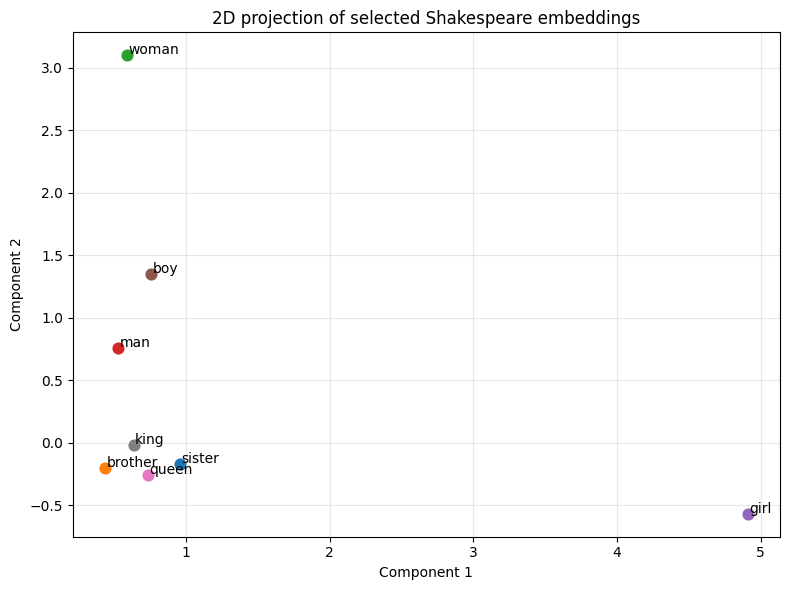

Saved plot file: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\A2_embedding_svd.png


In [10]:
words = selected_words

plt.figure(figsize=(8, 6))
for index, word in enumerate(words):
    plt.scatter(vectors_2d[index, 0], vectors_2d[index, 1], s=60)
    plt.text(vectors_2d[index, 0] + 0.01, vectors_2d[index, 1] + 0.01, word)

plt.title("2D projection of selected Shakespeare embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Saved plot file:", metrics["artifact_paths"]["svd_plot"])


## 6. Save Structured Metrics

Metrics are written by `run_experiments(...)` and reused by the final Chinese report builder.

In [11]:
metrics_path = Path(metrics["artifact_paths"]["metrics_file"])
print("Metrics file:", metrics_path.resolve())
print(metrics_path.read_text(encoding="utf-8")[:1200])


Metrics file: D:\OneDrive\Study\2026 Spring\Natural Language Processing\Assignment2\A2_code\A2_metrics.json
{
  "teacher_standard": {
    "analogy_topn": 5,
    "passing_accuracy_hint": 0.01
  },
  "raw_corpus_stats": {
    "line_count": 40000,
    "nonempty_line_count": 32777,
    "raw_token_count": 203839,
    "raw_vocab_size": 12373
  },
  "runs": {
    "set1": {
      "name": "set1",
      "config": {
        "name": "set1",
        "emb_size": 100,
        "window_size": 3,
        "negative_samples": 5,
        "min_count": 2,
        "embedding_mode": "input",
        "seed": 42,
        "epochs": 3,
        "batch_size": 128,
        "learning_rate": 0.025,
        "negative_table_size": 1000000,
        "analogy_topn": 5,
        "device": "cpu"
      },
      "corpus_stats": {
        "filtered_token_count": 198320,
        "filtered_vocab_size": 6854,
        "usable_lines": 27281,
        "training_pairs": 833158
      },
      "loss_history": [
        3.074113380855196,
 